# Project 2 — Deep Q-Network (DQN) on `Pong`
### RL in Production Workshop · Assignment

**Goal:** Build a **DQN from scratch in PyTorch** and train it to beat the built-in
Pong AI. You will implement the three ideas that make deep Q-learning actually work:
**experience replay**, a **target network**, and the **TD loss**.

> This is Project 1's Q-learning, but the 500-row table is replaced by a convolutional
> neural network that reads raw pixels. The update rule is *the same Bellman target* —
> we just minimize it with gradient descent.

---
### ⚠️ Before you start — runtime & expectations
- **Use a GPU runtime:** `Runtime → Change runtime type → T4 GPU`.
- Pong reaches a clearly winning policy (score **+15 to +21**) in roughly **1–3 hours**
  of training on a T4. **Start early.** Checkpointing to Google Drive (provided) lets
  you resume after Colab disconnects.
- You are graded on a *correct implementation* + evidence of learning, **not** on
  hitting +21. A reward curve that clearly trends upward past 0 is a pass.

### How this notebook works
- **`# ✅ PROVIDED`** cells (env wrappers, CNN, training loop, checkpointing, GIF) are
  done for you — read them.
- **`# 📝 TODO`** cells are yours: the **replay buffer**, the **DQN loss/optimize step**,
  the **target-network sync**, and the **epsilon schedule**.


## 1. Setup  ✅ PROVIDED

We install Gymnasium's Atari support + the ROMs, and import PyTorch.

In [1]:
# ✅ PROVIDED — install
# NOTE: opencv-python is required by AtariPreprocessing (frame resize/grayscale).
# Colab usually ships it, but we install it explicitly so the notebook is self-contained.
!pip install -q --upgrade pip
!pip install -q "gymnasium[atari,accept-rom-license]" ale-py "autorom[accept-rom-license]" opencv-python torch torchvision imageio
!AutoROM --accept-license -q || true

import os, random, time, math
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import ale_py
import matplotlib.pyplot as plt

gym.register_envs(ale_py)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
assert DEVICE == "cuda", "Switch to a GPU runtime: Runtime → Change runtime type → T4 GPU"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Usage: AutoROM [OPTIONS]
Try 'AutoROM --help' for help.

Error: No such option '-q'.
Device: cuda


## 2. Environment & preprocessing  ✅ PROVIDED — but read carefully

Raw Atari frames are 210×160 RGB and run at 60 Hz. Feeding those directly to a network
is wasteful and loses motion information. The standard **Atari preprocessing** pipeline:

1. **Grayscale + resize to 84×84** — color is irrelevant, smaller is faster.
2. **Frame-skip (4) with max-pooling** — repeat each action 4 frames; saves compute.
3. **Frame-stacking (4)** — stack the last 4 frames as channels so the network can
   perceive **velocity** (where the ball/paddle is *going*, not just where it is).
4. **Reward clipping to {−1, 0, +1}** — stabilizes the loss scale across games.

Gymnasium provides these as wrappers, so you don't have to write them.

In [2]:
# ✅ PROVIDED — build the wrapped Pong environment
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

def make_env(render_mode=None):
    # Important: frameskip=1 disables built-in env frame skipping.
    # AtariPreprocessing will apply frame_skip=4 below.
    env = gym.make("ALE/Pong-v5", render_mode=render_mode, frameskip=1)

    env = AtariPreprocessing(
        env,
        noop_max=30,
        frame_skip=4,
        screen_size=84,
        grayscale_obs=True,
        scale_obs=False,
    )

    env = FrameStackObservation(env, stack_size=4)
    return env

env = make_env()
print("Observation shape:", np.array(env.reset(seed=SEED)[0]).shape)
print("Number of actions:", env.action_space.n)

Observation shape: (4, 84, 84)
Number of actions: 6


**✍️ Quick check (write your answer):** Why do we stack **4 frames** instead of
feeding a single 84×84 image? What information would a single frame be missing?
*(your answer here)*

## 3. The Q-network (CNN)  ✅ PROVIDED

This is the classic architecture from Mnih et al. (2015), *"Human-level control through
deep reinforcement learning"* (the Nature DQN paper). Input: 4×84×84. Output: one
Q-value **per action** — so a single forward pass gives `Q(s, ·)` for all actions at once.

In [3]:
# ✅ PROVIDED — Nature-DQN CNN
class QNetwork(nn.Module):
    def __init__(self, n_actions):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512), nn.ReLU(),
            nn.Linear(512, n_actions),
        )

    def forward(self, x):
        # x: (B, 4, 84, 84) uint8 in [0,255] -> scale to [0,1]
        x = x.float() / 255.0
        x = self.features(x)
        x = x.reshape(x.size(0), -1)
        return self.head(x)

n_actions = env.action_space.n
net = QNetwork(n_actions).to(DEVICE)
print(net)
print("Params:", sum(p.numel() for p in net.parameters()))

QNetwork(
  (features): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=6, bias=True)
  )
)
Params: 1687206


**bold text**## 4. Experience Replay buffer  📝 TODO

**Why this exists:** consecutive frames are highly correlated. Training a network on
correlated samples is unstable and overfits to the recent trajectory. The replay buffer
stores transitions `(s, a, r, s', done)` and lets us sample **random minibatches** —
breaking correlation and reusing each experience many times (sample efficiency).

Implement the ring buffer below. Use a `collections.deque(maxlen=capacity)` so old
transitions are dropped automatically.

In [4]:
# 📝 TODO — experience replay buffer
class ReplayBuffer:
    def __init__(self, capacity):
        # Create a fixed-size replay buffer.
        # When it reaches capacity, old transitions are automatically removed.
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Store one transition. state/next_state are (4,84,84) numpy arrays."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Return a random minibatch as torch tensors on DEVICE."""
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        states      = torch.as_tensor(np.array(states),      dtype=torch.uint8 ).to(DEVICE)
        next_states = torch.as_tensor(np.array(next_states), dtype=torch.uint8 ).to(DEVICE)
        actions     = torch.as_tensor(actions,               dtype=torch.long  ).to(DEVICE)
        rewards     = torch.as_tensor(rewards,               dtype=torch.float32).to(DEVICE)
        dones       = torch.as_tensor(dones,                 dtype=torch.float32).to(DEVICE)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

# sanity check
_buf = ReplayBuffer(100)
_dummy = np.zeros((4, 84, 84), dtype=np.uint8)

for _ in range(10):
    _buf.push(_dummy, 1, 1.0, _dummy, False)

assert len(_buf) == 10

s, a, r, ns, d = _buf.sample(4)

assert s.shape == (4, 4, 84, 84) and a.shape == (4,)

print("ReplayBuffer works ✅")

ReplayBuffer works ✅


## 5. Epsilon schedule  📝 TODO

Same exploration idea as Project 1, but here ε is annealed **linearly** over the first
~1M frames from `1.0` to `0.1`, then held constant. Implement the schedule as a function
of the global frame counter.

In [5]:
# 📝 TODO — linear epsilon schedule
EPS_START   = 1.0
EPS_END     = 0.1
EPS_DECAY_FRAMES = 1_000_000   # anneal over the first 1M frames

def get_epsilon(frame_idx):
    """Linearly interpolate from EPS_START to EPS_END over EPS_DECAY_FRAMES,
    then stay at EPS_END."""
    fraction = min(1.0, frame_idx / EPS_DECAY_FRAMES)
    epsilon = EPS_START + fraction * (EPS_END - EPS_START)
    return epsilon

assert abs(get_epsilon(0) - 1.0) < 1e-6
assert abs(get_epsilon(EPS_DECAY_FRAMES) - 0.1) < 1e-6
assert abs(get_epsilon(10 * EPS_DECAY_FRAMES) - 0.1) < 1e-6

print("epsilon schedule works ✅")

epsilon schedule works ✅


## 6. The DQN loss & target network  📝 TODO — the core of the project

Two networks:
- **`policy_net`** — the one we train every step (selects actions).
- **`target_net`** — a *frozen copy* used only to compute the TD target. We sync it to
  `policy_net` every `TARGET_UPDATE` steps.

**Why the target network?** If we bootstrapped off the *same* network we're updating,
the target moves every gradient step — we'd be "chasing our own tail," and Q-values
diverge. Freezing the target stabilizes learning. (You'll prove this with an ablation.)

The loss, for a sampled minibatch:

$$
y_i = r_i + \gamma \,(1 - \text{done}_i)\, \max_{a'} Q_{\text{target}}(s'_i, a')
$$
$$
\mathcal{L} = \frac{1}{N}\sum_i \big( Q_{\text{policy}}(s_i, a_i) - y_i \big)^2 \quad\text{(Huber/SmoothL1 in practice)}
$$

Implement `compute_td_loss`. Key PyTorch detail: the target `y` must be computed under
`torch.no_grad()` (no gradients flow into the target network).

In [6]:
# 📝 TODO — DQN loss
GAMMA = 0.99

def compute_td_loss(policy_net, target_net, batch):
    states, actions, rewards, next_states, dones = batch

    # (1) Q(s, a) for the actions actually taken.
    # policy_net(states) gives Q-values for all actions: shape (B, n_actions)
    # gather selects the Q-value for the action that was actually taken.
    q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # (2) TD target using the target network.
    # No gradients should flow through the target network.
    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1).values
        td_target = rewards + GAMMA * (1 - dones) * next_q

    # (3) Huber loss between predicted Q-value and TD target.
    loss = F.smooth_l1_loss(q_values, td_target)

    return loss

print("Loss function defined ✅")

Loss function defined ✅


## 7. Training loop  ✅ PROVIDED — wires your pieces together

Read this carefully: it shows exactly **how your four TODO pieces interact**. You only
need to make sure the earlier cells run. Note the marked **target-network sync** — it
uses `load_state_dict`, the deep-learning analogue of "copy the table."

Hyperparameters are tuned to reach a winning Pong agent on a T4.

In [7]:
# ✅ PROVIDED — agent + training loop
# --- hyperparameters ---
REPLAY_CAPACITY   = 100_000
LEARNING_START    = 10_000     # frames of random play before learning
BATCH_SIZE        = 32
LEARNING_RATE     = 1e-4
TARGET_UPDATE     = 1_000      # sync target_net every N gradient steps
TRAIN_FREQ        = 4          # one gradient step every 4 frames
TOTAL_FRAMES      = 2_000_000  # ~enough to win Pong; reduce for a quick smoke test

# --- networks & optimizer ---
policy_net = QNetwork(n_actions).to(DEVICE)
target_net = QNetwork(n_actions).to(DEVICE)
target_net.load_state_dict(policy_net.state_dict())   # start identical
target_net.eval()
optimizer = torch.optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
buffer = ReplayBuffer(REPLAY_CAPACITY)

def select_action(state, epsilon):
    if random.random() < epsilon:
        return env.action_space.sample()
    with torch.no_grad():
        s = torch.as_tensor(np.array(state), dtype=torch.uint8).unsqueeze(0).to(DEVICE)
        return int(policy_net(s).argmax(dim=1).item())

# --- main loop ---
def train(total_frames=TOTAL_FRAMES, log_every=10):
    episode_rewards, recent = [], deque(maxlen=100)
    state, _ = env.reset(seed=SEED)
    state = np.array(state)
    ep_reward, grad_steps, ep = 0, 0, 0
    t0 = time.time()

    for frame in range(1, total_frames + 1):
        epsilon = get_epsilon(frame)
        action = select_action(state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        next_state = np.array(next_state)
        done = terminated or truncated

        buffer.push(state, action, np.sign(reward), next_state, float(done))  # reward clipping
        state = next_state
        ep_reward += reward

        if done:
            episode_rewards.append(ep_reward); recent.append(ep_reward); ep += 1
            state, _ = env.reset(); state = np.array(state)
            if ep % log_every == 0:
                fps = frame / (time.time() - t0)
                print(f"ep {ep:4d} | frame {frame:8d} | eps {epsilon:.2f} | "
                      f"avg100 {np.mean(recent):6.2f} | {fps:4.0f} fps")
            ep_reward = 0

        # learn
        if len(buffer) >= LEARNING_START and frame % TRAIN_FREQ == 0:
            batch = buffer.sample(BATCH_SIZE)
            loss = compute_td_loss(policy_net, target_net, batch)
            optimizer.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
            optimizer.step()
            grad_steps += 1

            # 🔑 target network sync — the DQN stability trick
            if grad_steps % TARGET_UPDATE == 0:
                target_net.load_state_dict(policy_net.state_dict())

        if frame % 100_000 == 0:
            save_checkpoint(frame, episode_rewards)

    return episode_rewards

## 8. Checkpointing to Google Drive  ✅ PROVIDED

Colab disconnects. Mount Drive so you can **resume** instead of restarting. Run this
*before* training; if a checkpoint exists it will be loaded.

In [8]:
# ✅ PROVIDED — Drive checkpointing
from google.colab import drive
drive.mount("/content/drive")
CKPT_DIR = "/content/drive/MyDrive/dqn_pong"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, "checkpoint.pt")

def save_checkpoint(frame, episode_rewards):
    torch.save({
        "frame": frame,
        "policy": policy_net.state_dict(),
        "target": target_net.state_dict(),
        "optim": optimizer.state_dict(),
        "rewards": episode_rewards,
    }, CKPT_PATH)
    print(f"  💾 checkpoint saved @ frame {frame}")

def load_checkpoint():
    if os.path.exists(CKPT_PATH):
        ck = torch.load(CKPT_PATH, map_location=DEVICE)
        policy_net.load_state_dict(ck["policy"])
        target_net.load_state_dict(ck["target"])
        optimizer.load_state_dict(ck["optim"])
        print(f"Resumed from frame {ck['frame']} ({len(ck['rewards'])} episodes)")
        return ck["rewards"]
    print("No checkpoint found — starting fresh.")
    return []

_ = load_checkpoint()

Mounted at /content/drive
Resumed from frame 900000 (687 episodes)


## 9. Train!  ✅ PROVIDED

This runs for a long time. Pong reward starts at **−21** (agent loses every point) and
should climb past **0** and toward **+20**. Watch `avg100` rise.

> **Smoke test first:** before committing to the full run, set `total_frames=50_000`
> to confirm the whole pipeline runs end-to-end without errors. Then run the full
> training.

In [9]:
# ✅ PROVIDED — start training
rewards = train(total_frames=TOTAL_FRAMES)

ep   10 | frame     9275 | eps 0.99 | avg100 -20.30 | 2376 fps
ep   20 | frame    18795 | eps 0.98 | avg100 -20.25 | 1642 fps
ep   30 | frame    27998 | eps 0.97 | avg100 -20.33 | 1506 fps
ep   40 | frame    37778 | eps 0.97 | avg100 -20.25 | 1444 fps
ep   50 | frame    47024 | eps 0.96 | avg100 -20.24 | 1410 fps
ep   60 | frame    55914 | eps 0.95 | avg100 -20.30 | 1388 fps
ep   70 | frame    65435 | eps 0.94 | avg100 -20.27 | 1368 fps
ep   80 | frame    75485 | eps 0.93 | avg100 -20.26 | 1351 fps
ep   90 | frame    85414 | eps 0.92 | avg100 -20.26 | 1339 fps
ep  100 | frame    95736 | eps 0.91 | avg100 -20.18 | 1329 fps
  💾 checkpoint saved @ frame 100000
ep  110 | frame   106364 | eps 0.90 | avg100 -20.13 | 1319 fps
ep  120 | frame   116041 | eps 0.90 | avg100 -20.09 | 1312 fps
ep  130 | frame   126168 | eps 0.89 | avg100 -20.06 | 1305 fps
ep  140 | frame   136717 | eps 0.88 | avg100 -20.05 | 1299 fps
ep  150 | frame   147916 | eps 0.87 | avg100 -20.01 | 1293 fps
ep  160 | frame   1

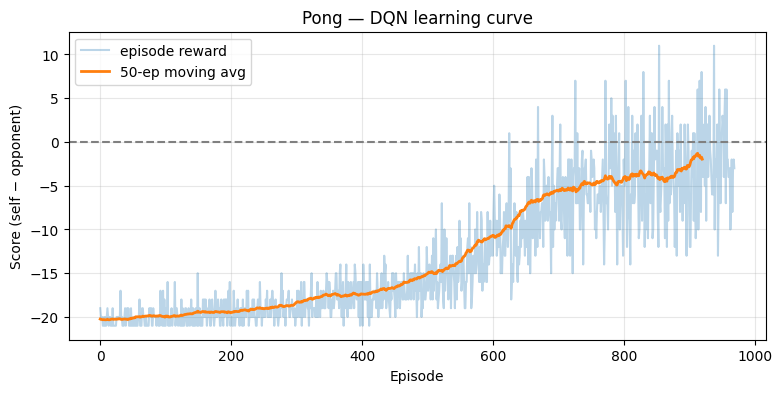

In [10]:
# ✅ Load checkpoint and plot learning curve

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
# ✅ PROVIDED — plot the learning curve
def moving_average(x, w=50):
    return np.convolve(x, np.ones(w)/w, mode="valid") if len(x) >= w else x

plt.figure(figsize=(9, 4))
plt.plot(rewards, alpha=0.3, label="episode reward")
plt.plot(moving_average(rewards), linewidth=2, label="50-ep moving avg")
plt.axhline(0, color="gray", ls="--")
plt.title("Pong — DQN learning curve")
plt.xlabel("Episode")
plt.ylabel("Score (self − opponent)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 10. Watch your agent play — record a GIF  ✅ PROVIDED

Greedy rollout rendered to an animated GIF you can embed and submit. This is the
satisfying payoff — your network playing Pong from pixels.

Episode score: 12.0  |  frames: 2524


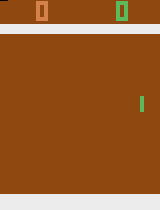

In [11]:
# ✅ PROVIDED — record a greedy episode to GIF
import imageio
from IPython.display import Image as IPyImage

def record_gif(path="/content/pong.gif", max_steps=3000):
    play_env = make_env(render_mode="rgb_array")
    state, _ = play_env.reset(seed=123); state = np.array(state)
    frames, done, R = [], False, 0
    while not done and len(frames) < max_steps:
        frames.append(play_env.render())
        with torch.no_grad():
            s = torch.as_tensor(state, dtype=torch.uint8).unsqueeze(0).to(DEVICE)
            a = int(policy_net(s).argmax(1).item())
        state, r, term, trunc, _ = play_env.step(a)
        state = np.array(state); done = term or trunc; R += r
    imageio.mimsave(path, frames[::2], fps=30)
    print(f"Episode score: {R}  |  frames: {len(frames)}")
    return path

gif_path = record_gif()
IPyImage(filename=gif_path)

## 11. Ablations & written analysis  📝 TODO (written)

**A. Kill the target network.** Set `TARGET_UPDATE = 1` (sync every step ≈ no target
network) and train a short run. Plot the Q-value magnitude / reward. **✍️ What happens
to stability and why?
** *(answer)*
(Raghavan) When I set TARGET_UPDATE = 1, the agent did not show meaningful reward improvement during the short run. The reward curve stayed around -20, meaning the agent continued to lose almost every game. The Q-value magnitude increased over training but was noisy, and the TD loss had frequent spikes. This suggests the value estimates were less stable when the target network was synced every step. The reason is that the TD target changes every time the policy network changes, so the model is effectively chasing a moving target. A frozen target network stabilizes learning by keeping the bootstrapped target fixed for many updates before syncing.


**B. Tiny replay buffer.** Set `REPLAY_CAPACITY = 1000`. **✍️ How does correlated /
stale data hurt learning?** *(answer)*


(Raghavan) With REPLAY_CAPACITY = 1000, the reward curve stayed around -20 and did not show meaningful improvement. In my run, the Q-value magnitude and TD-loss plots were empty because the learning_start value was larger than the replay buffer capacity, so the agent did not actually begin gradient updates. This shows *implementation issue*: if the replay buffer is too small relative to the learning-start threshold, training never starts. Conceptually, even when training is enabled, a tiny replay buffer hurts DQN because the model trains mostly on recent, highly correlated Pong frames. This reduces minibatch diversity, makes updates noisier, and weakens the stabilizing benefit of experience replay.


**C. No frame stacking.** (Conceptual — you don't have to rerun.) **✍️ Why would a
Pong agent that sees only single frames be fundamentally handicapped?** *(answer)*

(Raghavan) A Pong agent that sees only a single frame is fundamentally handicapped because one image only shows the current positions of the ball and paddles, not their motion. The agent cannot tell whether the ball is moving toward the paddle or away from it, or whether it is moving upward or downward. Two situations can look identical in a single frame but require different actions depending on the ball’s velocity. Frame stacking solves this by giving the network a short history of recent frames, allowing it to infer direction and speed. Without frame stacking, the agent has incomplete state information and will make worse decisions.


## 12. From notebook to production — discussion  📝 TODO (written)

You now have a working DQN. In a real deployed system, plain DQN rarely survives
unchanged. In 4–6 sentences, address **at least three** of:

- **Sample efficiency:** this took ~1–2M frames for *one* game. What does that imply
  for a robot or a recommender that can't cheaply simulate millions of interactions?
- **Exploration cost:** random actions are free in a simulator. What's the cost of
  ε-greedy exploration in a live production system (ads, trading, healthcare)?
- **Non-stationarity / distribution shift:** the world changes after deployment. Why
  is that a problem for a Q-function trained on yesterday's data?
- **Safety & off-policy evaluation:** how would you estimate whether a new policy is
  better *before* letting it act for real? (This motivates **offline RL**.)

**✍️ Your analysis:** *(write here)*

Plain DQN needs a large number of interactions, so it works well in cheap simulators like Pong but is harder to use directly in robotics or recommender systems where every action has real cost. In production, ε-greedy exploration can hurt users because random actions may show bad recommendations, waste ad spend, make unsafe trades, or choose poor healthcare actions. A Q-function trained on yesterday’s data can also become stale because user behavior, item inventory, competitors, and external conditions change over time. This distribution shift means the learned value estimates may no longer match the current environment. Before deploying a new policy, I would evaluate it offline using logged data, counterfactual evaluation, replay simulation, and small controlled A/B tests with guardrails. Overall, a production RL system needs safer exploration, better sample efficiency, monitoring, and off-policy evaluation rather than using plain DQN unchanged.


---
## ✅ Submission checklist
- [ x] `ReplayBuffer`, `get_epsilon`, and `compute_td_loss` implemented; sanity checks pass.
- [ x] Smoke test (50k frames) ran with no errors.
- [ x] Full training learning curve attached; reward clearly trends upward (past 0).
- [ x] Embedded GIF of the trained agent playing.
- [ x] Ablations A–C answered.
- [ x] Production discussion (Section 12) answered.
check code below for ablations
**Submit:** this notebook with all cells run + the `pong.gif`.

In [12]:
## Ablation  code
# 📝 TODO — Ablations for DQN Pong

import time
import random
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Make sure DEVICE exists
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

def moving_average(x, w=50):
    return np.convolve(x, np.ones(w) / w, mode="valid") if len(x) >= w else x


def select_action_ablation(env, policy_net_local, state, epsilon):
    """Epsilon-greedy action selection for ablation runs."""
    if random.random() < epsilon:
        return env.action_space.sample()

    with torch.no_grad():
        s = torch.as_tensor(np.array(state), dtype=torch.uint8).unsqueeze(0).to(DEVICE)
        return int(policy_net_local(s).argmax(dim=1).item())


def run_dqn_ablation(
    name,
    target_update,
    replay_capacity,
    total_frames=200_000,
    learning_start=10_000,
    batch_size=32,
    train_freq=4,
    learning_rate=1e-4,
    log_every=10,
):
    """
    Runs a short DQN training experiment for ablation.

    name: label for plots
    target_update: how often to sync target_net to policy_net
                   target_update=1 approximates killing the target network
    replay_capacity: replay buffer size
    """

    print(f"\n===== Running ablation: {name} =====")
    print(f"target_update={target_update}, replay_capacity={replay_capacity}, total_frames={total_frames}")

    # Create a fresh environment
    ablation_env = make_env()
    n_actions_local = ablation_env.action_space.n

    # Fresh networks for ablation
    policy_net_local = QNetwork(n_actions_local).to(DEVICE)
    target_net_local = QNetwork(n_actions_local).to(DEVICE)
    target_net_local.load_state_dict(policy_net_local.state_dict())
    target_net_local.eval()

    optimizer_local = torch.optim.Adam(policy_net_local.parameters(), lr=learning_rate)
    buffer_local = ReplayBuffer(replay_capacity)

    episode_rewards = []
    recent = deque(maxlen=100)

    q_frames = []
    q_magnitudes = []
    losses = []

    state, _ = ablation_env.reset(seed=SEED)
    state = np.array(state)

    ep_reward = 0
    grad_steps = 0
    ep = 0
    t0 = time.time()

    for frame in range(1, total_frames + 1):
        epsilon = get_epsilon(frame)

        action = select_action_ablation(ablation_env, policy_net_local, state, epsilon)

        next_state, reward, terminated, truncated, _ = ablation_env.step(action)
        next_state = np.array(next_state)
        done = terminated or truncated

        # Store clipped reward, same as main training
        buffer_local.push(state, action, np.sign(reward), next_state, float(done))

        state = next_state
        ep_reward += reward

        if done:
            episode_rewards.append(ep_reward)
            recent.append(ep_reward)
            ep += 1

            state, _ = ablation_env.reset()
            state = np.array(state)

            if ep % log_every == 0:
                fps = frame / (time.time() - t0)
                print(
                    f"{name} | ep {ep:4d} | frame {frame:8d} | "
                    f"eps {epsilon:.2f} | avg100 {np.mean(recent):6.2f} | {fps:4.0f} fps"
                )

            ep_reward = 0

        # Learn
        if len(buffer_local) >= learning_start and frame % train_freq == 0:
            batch = buffer_local.sample(batch_size)

            loss = compute_td_loss(policy_net_local, target_net_local, batch)

            optimizer_local.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(policy_net_local.parameters(), 10.0)
            optimizer_local.step()

            grad_steps += 1

            # Target-network sync
            if grad_steps % target_update == 0:
                target_net_local.load_state_dict(policy_net_local.state_dict())

            # Track Q-value magnitude occasionally
            if grad_steps % 100 == 0:
                states, actions, rewards, next_states, dones = batch

                with torch.no_grad():
                    q_abs_mean = policy_net_local(states).abs().mean().item()

                q_frames.append(frame)
                q_magnitudes.append(q_abs_mean)
                losses.append(loss.item())

    ablation_env.close()

    result = {
        "name": name,
        "episode_rewards": episode_rewards,
        "q_frames": q_frames,
        "q_magnitudes": q_magnitudes,
        "losses": losses,
    }

    return result


def plot_ablation_result(result):
    name = result["name"]
    rewards = result["episode_rewards"]
    q_frames = result["q_frames"]
    q_magnitudes = result["q_magnitudes"]
    losses = result["losses"]

    # Plot reward
    plt.figure(figsize=(9, 4))
    plt.plot(rewards, alpha=0.3, label="episode reward")
    plt.plot(moving_average(rewards), linewidth=2, label="50-ep moving avg")
    plt.axhline(0, color="gray", ls="--")
    plt.title(f"{name} — reward curve")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot Q-value magnitude
    plt.figure(figsize=(9, 4))
    plt.plot(q_frames, q_magnitudes, label="mean |Q(s, a)|")
    plt.title(f"{name} — Q-value magnitude")
    plt.xlabel("Frame")
    plt.ylabel("Mean absolute Q-value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Plot loss
    plt.figure(figsize=(9, 4))
    plt.plot(q_frames, losses, label="TD loss")
    plt.title(f"{name} — TD loss")
    plt.xlabel("Frame")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

Device: cuda



===== Running ablation: Ablation A: TARGET_UPDATE = 1 =====
target_update=1, replay_capacity=100000, total_frames=200000
Ablation A: TARGET_UPDATE = 1 | ep   10 | frame     8692 | eps 0.99 | avg100 -20.60 | 3027 fps
Ablation A: TARGET_UPDATE = 1 | ep   20 | frame    18270 | eps 0.98 | avg100 -20.55 | 1863 fps
Ablation A: TARGET_UPDATE = 1 | ep   30 | frame    27599 | eps 0.98 | avg100 -20.50 | 1618 fps
Ablation A: TARGET_UPDATE = 1 | ep   40 | frame    37050 | eps 0.97 | avg100 -20.27 | 1518 fps
Ablation A: TARGET_UPDATE = 1 | ep   50 | frame    46370 | eps 0.96 | avg100 -20.24 | 1464 fps
Ablation A: TARGET_UPDATE = 1 | ep   60 | frame    54906 | eps 0.95 | avg100 -20.35 | 1429 fps
Ablation A: TARGET_UPDATE = 1 | ep   70 | frame    64858 | eps 0.94 | avg100 -20.29 | 1400 fps
Ablation A: TARGET_UPDATE = 1 | ep   80 | frame    73866 | eps 0.93 | avg100 -20.30 | 1381 fps
Ablation A: TARGET_UPDATE = 1 | ep   90 | frame    83119 | eps 0.93 | avg100 -20.32 | 1365 fps
Ablation A: TARGET_UPDA

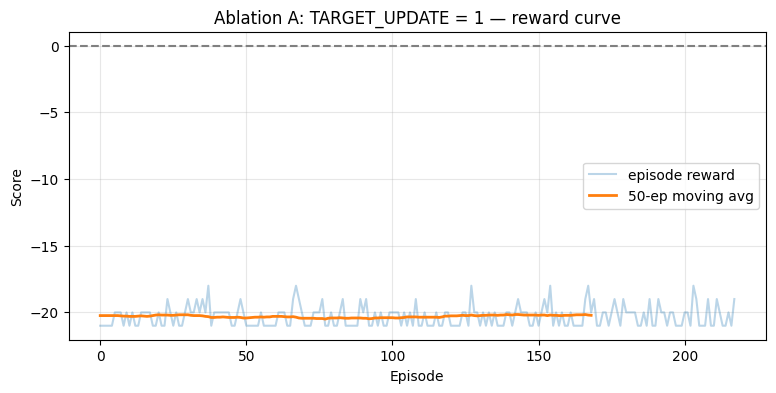

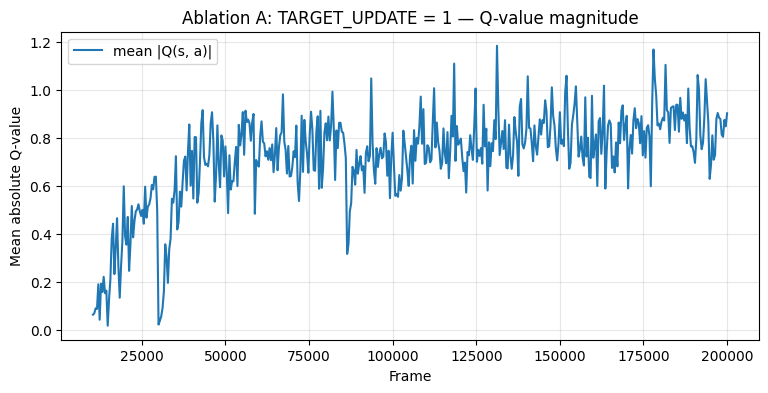

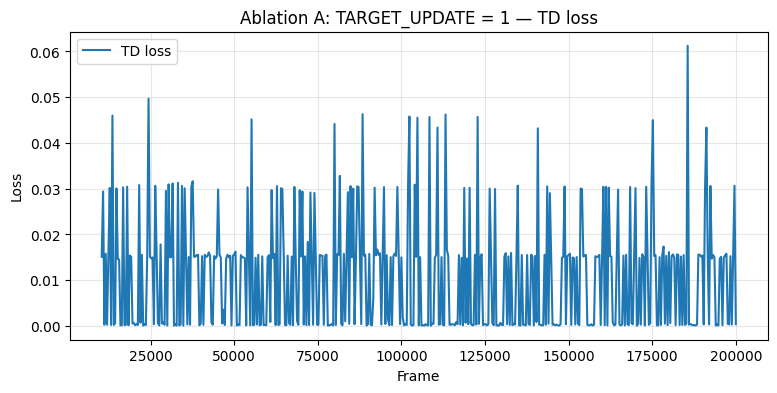

In [13]:
# A. Kill the target network
# TARGET_UPDATE = 1 means target_net is synced after every gradient step.
# This approximates not having a stable frozen target network.

ablation_A = run_dqn_ablation(
    name="Ablation A: TARGET_UPDATE = 1",
    target_update=1,
    replay_capacity=100_000,
    total_frames=200_000,
)

plot_ablation_result(ablation_A)


===== Running ablation: Ablation B: REPLAY_CAPACITY = 1000 =====
target_update=1000, replay_capacity=1000, total_frames=200000
Ablation B: REPLAY_CAPACITY = 1000 | ep   10 | frame     9586 | eps 0.99 | avg100 -20.40 | 3015 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   20 | frame    18935 | eps 0.98 | avg100 -20.40 | 3005 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   30 | frame    28558 | eps 0.97 | avg100 -20.23 | 2994 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   40 | frame    38066 | eps 0.97 | avg100 -20.23 | 2985 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   50 | frame    48041 | eps 0.96 | avg100 -20.10 | 2974 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   60 | frame    56928 | eps 0.95 | avg100 -20.17 | 2965 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   70 | frame    65852 | eps 0.94 | avg100 -20.19 | 2953 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   80 | frame    75237 | eps 0.93 | avg100 -20.19 | 2944 fps
Ablation B: REPLAY_CAPACITY = 1000 | ep   90 | frame    84515 | eps 0.92

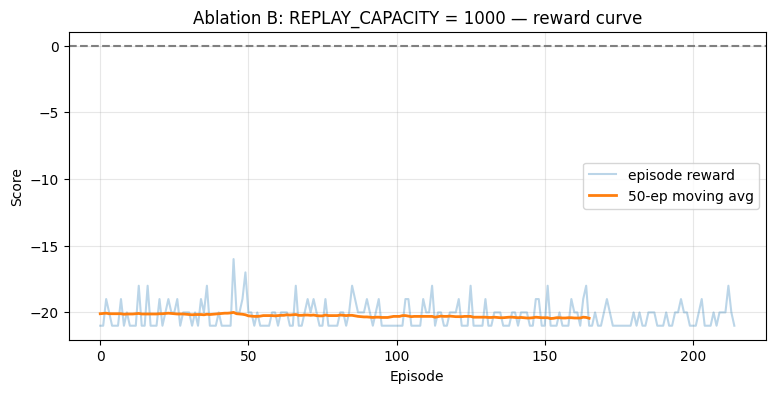

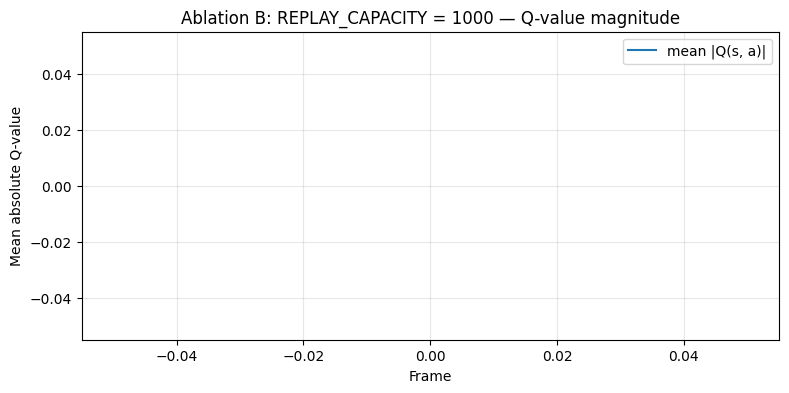

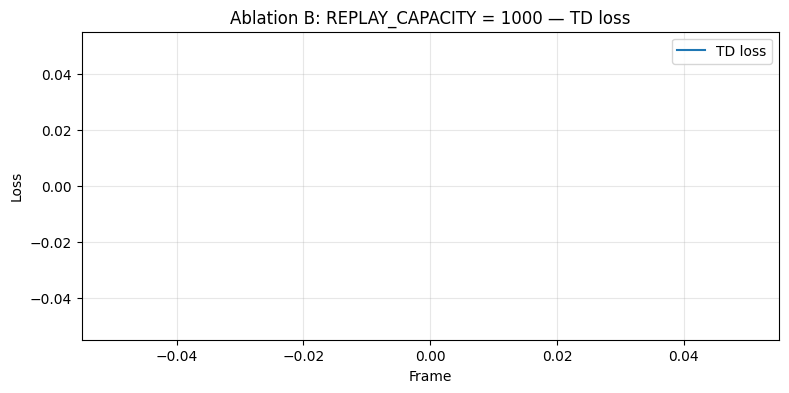


===== Running ablation: Baseline: normal target + large replay =====
target_update=1000, replay_capacity=100000, total_frames=200000
Baseline: normal target + large replay | ep   10 | frame     8924 | eps 0.99 | avg100 -20.90 | 3027 fps
Baseline: normal target + large replay | ep   20 | frame    17698 | eps 0.98 | avg100 -20.55 | 1990 fps
Baseline: normal target + large replay | ep   30 | frame    26766 | eps 0.98 | avg100 -20.43 | 1725 fps
Baseline: normal target + large replay | ep   40 | frame    35805 | eps 0.97 | avg100 -20.40 | 1616 fps
Baseline: normal target + large replay | ep   50 | frame    44960 | eps 0.96 | avg100 -20.44 | 1556 fps
Baseline: normal target + large replay | ep   60 | frame    54566 | eps 0.95 | avg100 -20.37 | 1514 fps
Baseline: normal target + large replay | ep   70 | frame    63683 | eps 0.94 | avg100 -20.39 | 1486 fps
Baseline: normal target + large replay | ep   80 | frame    73476 | eps 0.93 | avg100 -20.31 | 1463 fps
Baseline: normal target + large re

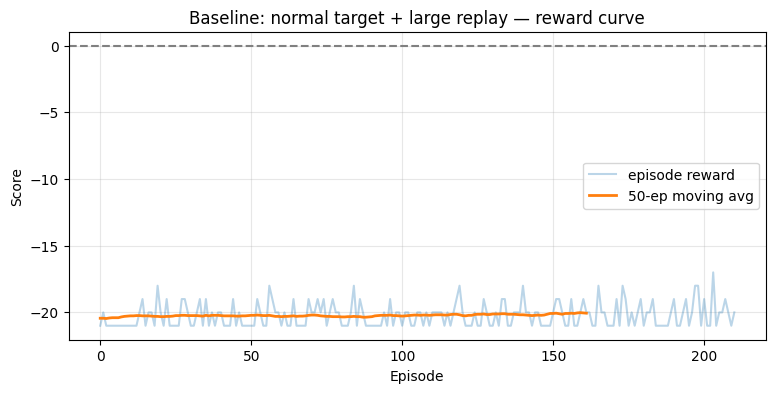

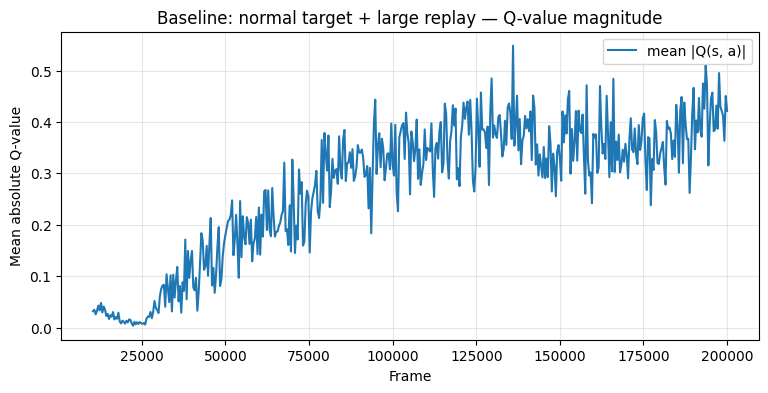

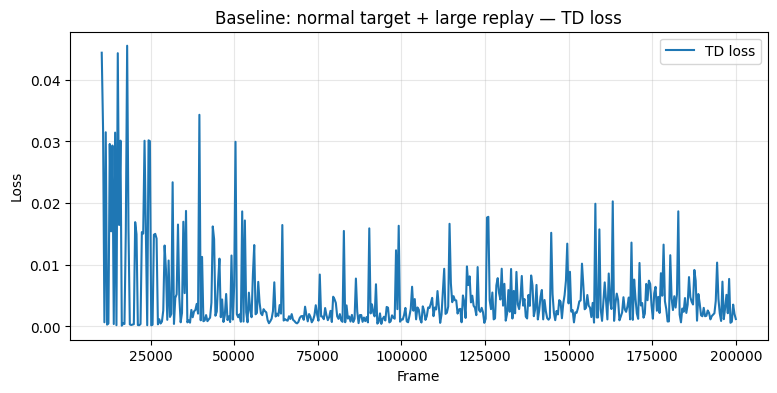

In [14]:
ablation_B = run_dqn_ablation(
    name="Ablation B: REPLAY_CAPACITY = 1000",
    target_update=1_000,
    replay_capacity=1_000,
    total_frames=200_000,
)

plot_ablation_result(ablation_B)
# Optional baseline
# Normal-ish short run with target network and large replay buffer.

baseline = run_dqn_ablation(
    name="Baseline: normal target + large replay",
    target_update=1_000,
    replay_capacity=100_000,
    total_frames=200_000,
)

plot_ablation_result(baseline)